# 📊 Visuals: Portfolio Performance Analysis
**Complements run_evaluation.py**

This notebook loads the results from `run_evaluation.py` and displays all charts.

**Workflow:**
1. Run `python run_evaluation.py` in terminal (generates portfolios + saves grand_comparison.csv)
2. Open this notebook and click **Run All**
3. Browse the 11 performance charts below

In [28]:
# ── Setup ─────────────────────────────────────────────────────────────────
%matplotlib inline
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="colorblind", font_scale=1.1)
PALETTE = sns.color_palette("colorblind", 12)

print("Loading data...")
df_raw = pd.read_parquet("../data/processed/test_data.parquet")
comp = pd.read_csv("../data/processed/grand_comparison.csv")

print(f"✓ test_data.parquet: {len(df_raw)} rows, {df_raw['eom'].nunique()} months")
print(f"✓ grand_comparison.csv: {len(comp)} portfolio combinations")
print("\nReady to visualize.")

Loading data...
✓ test_data.parquet: 290295 rows, 83 months
✓ grand_comparison.csv: 12 portfolio combinations

Ready to visualize.


In [29]:
# ── Helpers ───────────────────────────────────────────────────────────────
def _cum(r):  return (1 + r).cumprod()
def _dd(r):   c = _cum(r); return (1 - c / c.cummax())

def build_portfolio_returns(df, model, strategy, cost_bps=50.0):
    '''Rebuild a specific portfolio's monthly returns.'''
    if strategy == "LS_decile_EW":
        rets = []
        for date, grp in df.groupby("eom"):
            pred_col = f"ret_exc_pred_{model}"
            n = len(grp)
            top_n = max(1, int(0.10 * n))
            
            top_idx = grp[pred_col].nlargest(top_n).index
            top_ret = grp.loc[top_idx, "ret_exc_true"].mean()
            
            bot_idx = grp[pred_col].nsmallest(top_n).index
            bot_ret = grp.loc[bot_idx, "ret_exc_true"].mean()
            
            ls_ret = (top_ret - bot_ret) / 2.0
            turnover = 0.70
            cost = turnover * (cost_bps / 10000)
            net_ret = ls_ret - cost
            rets.append(net_ret)
    else:  # LongOnly_EW
        rets = []
        for date, grp in df.groupby("eom"):
            pred_col = f"ret_exc_pred_{model}"
            n = len(grp)
            top_n = max(1, int(0.10 * n))
            
            top_idx = grp[pred_col].nlargest(top_n).index
            top_ret = grp.loc[top_idx, "ret_exc_true"].mean()
            
            turnover = 0.70
            cost = turnover * (cost_bps / 10000)
            net_ret = top_ret - cost
            rets.append(net_ret)
    
    return pd.Series(rets, index=sorted(df["eom"].unique()))

# Rebuild all portfolios
print("Rebuilding all portfolios...")
all_ports = {}
for _, row in comp.iterrows():
    model = row["model"]
    strat = row["strategy"]
    all_ports[(model, strat)] = build_portfolio_returns(df_raw, model, strat)
print(f"✓ {len(all_ports)} portfolios ready")

Rebuilding all portfolios...
✓ 12 portfolios ready


---
## ① Cumulative Returns — $1 invested, net of costs

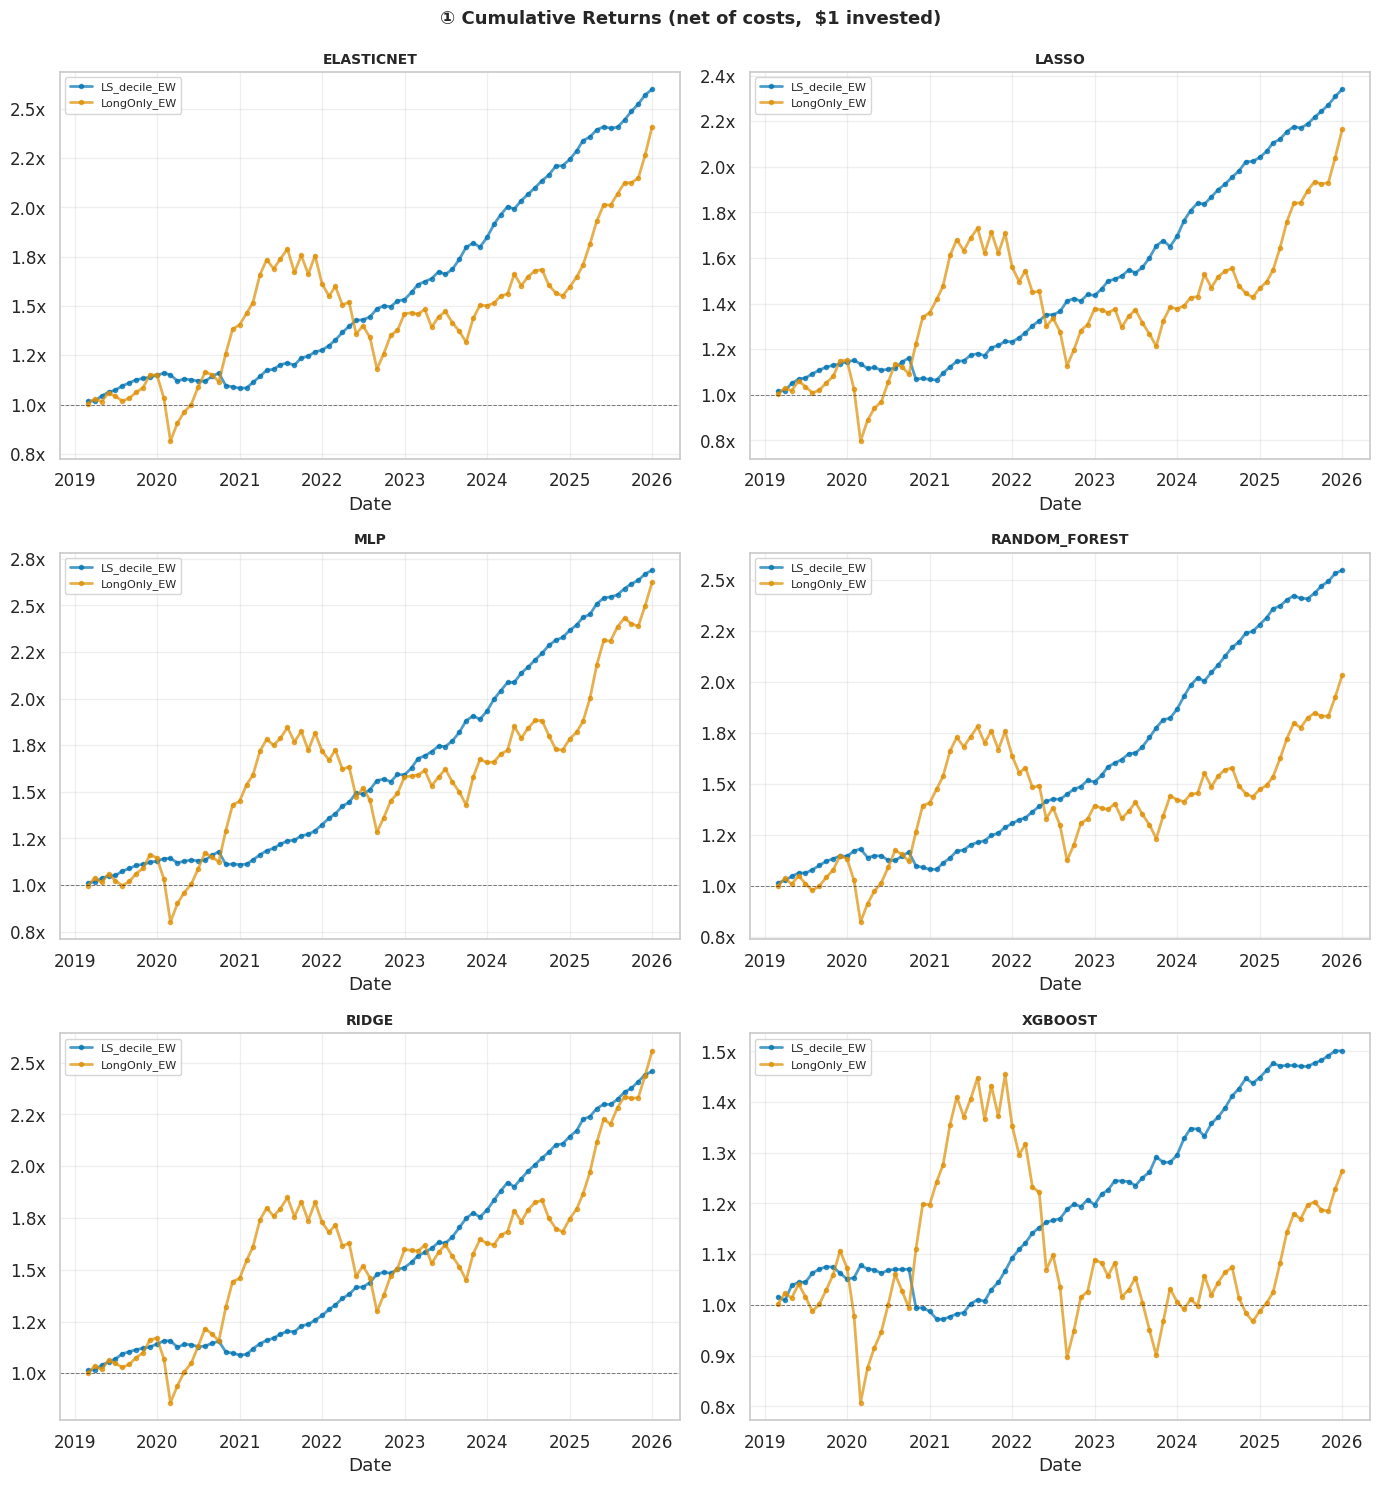

In [30]:
models = sorted(set(c[0] for c in all_ports.keys()))
n = len(models)
ncols = min(2, n); nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 5*nrows))
axes = np.array(axes).ravel()
fig.suptitle("① Cumulative Returns (net of costs,  $1 invested)",
             fontsize=13, fontweight="bold", y=0.99)

colors = sns.color_palette("colorblind", 12)
strat_colors = {"LS_decile_EW": colors[0], "LongOnly_EW": colors[1]}

for ax, m in zip(axes, models):
    for (model, strat), ret_series in all_ports.items():
        if model != m: continue
        c = _cum(ret_series)
        ax.plot(c.index, c.values, lw=2, color=strat_colors[strat], 
                label=strat, marker="o", markersize=3, alpha=0.7)
    ax.axhline(1, color="black", lw=0.7, ls="--", alpha=0.5)
    ax.set_title(m.upper(), fontweight="bold", fontsize=10)
    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.1fx"))
    ax.legend(fontsize=8, loc="upper left")
    ax.set_xlabel("Date"); ax.grid(True, alpha=0.3)

for ax in axes[n:]: ax.set_visible(False)
plt.tight_layout(); plt.show()

---
## ② Drawdown Charts — underwater analysis

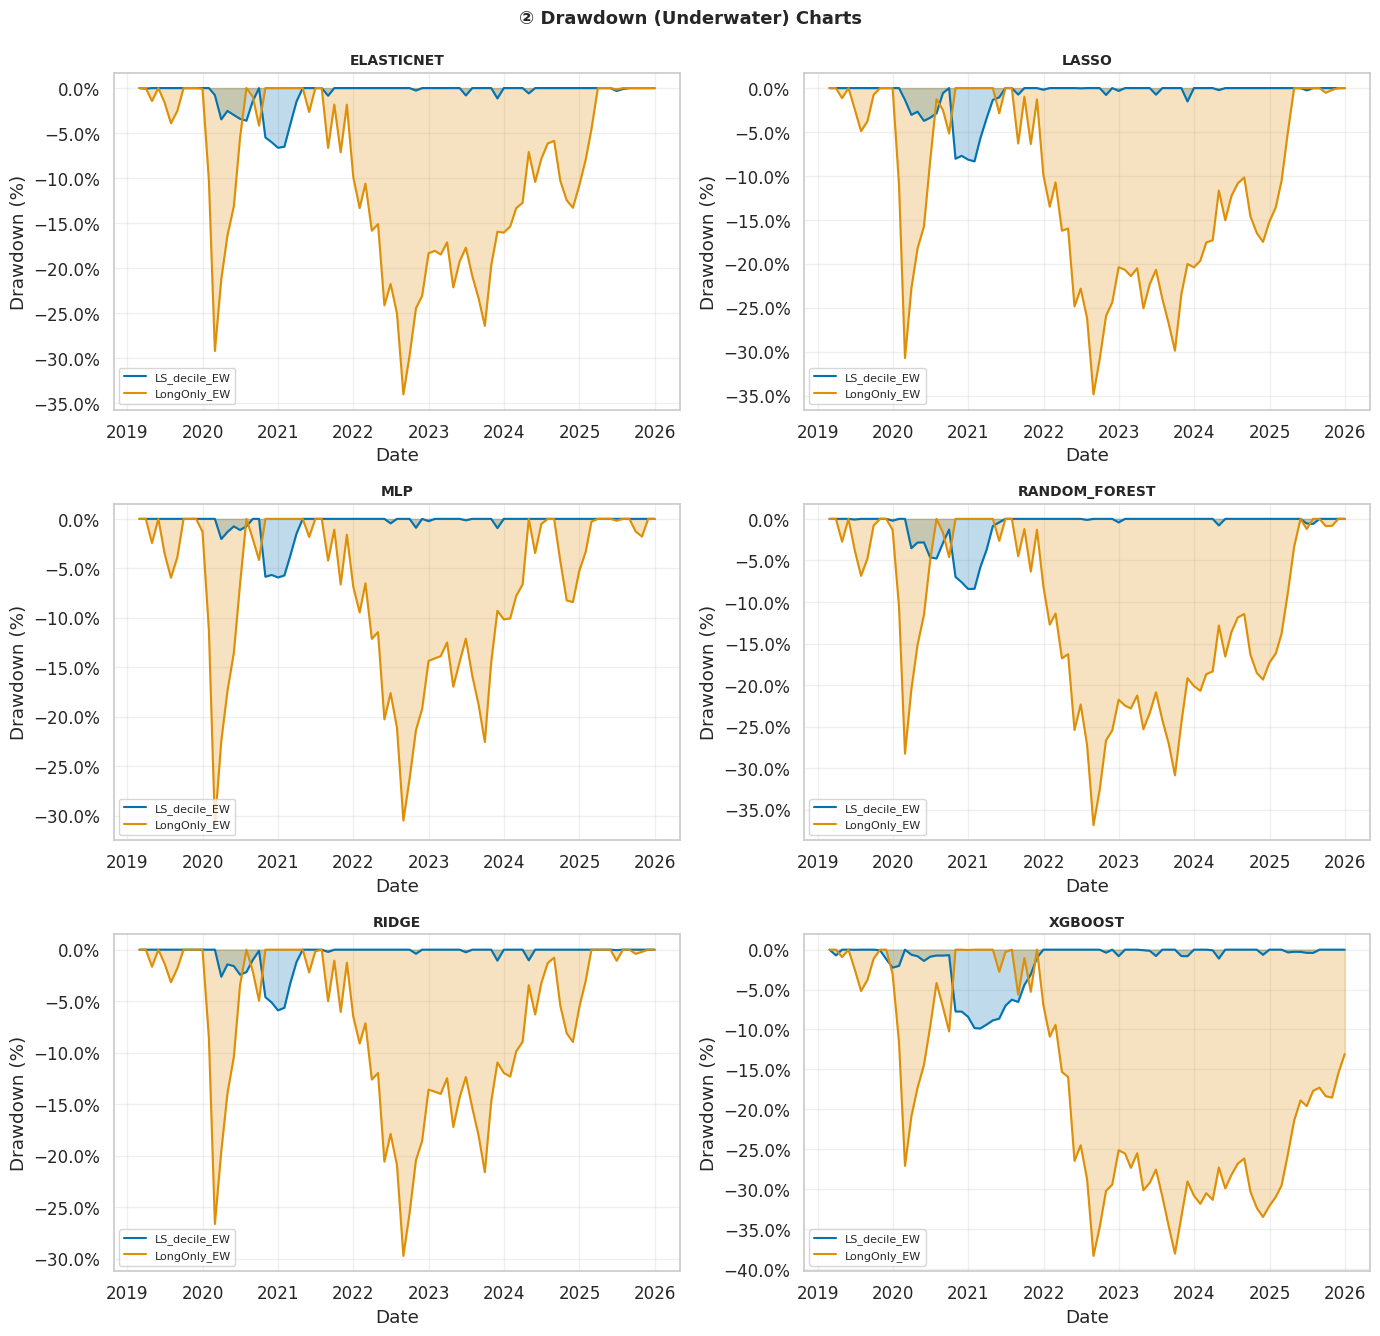

In [31]:
models = sorted(set(c[0] for c in all_ports.keys()))
n = len(models)
ncols = min(2, n); nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4.5*nrows))
axes = np.array(axes).ravel()
fig.suptitle("② Drawdown (Underwater) Charts",
             fontsize=13, fontweight="bold", y=0.99)

strat_colors = {"LS_decile_EW": colors[0], "LongOnly_EW": colors[1]}

for ax, m in zip(axes, models):
    for (model, strat), ret_series in all_ports.items():
        if model != m: continue
        dd = _dd(ret_series) * 100
        ax.fill_between(dd.index, -dd.values, 0, alpha=0.25, 
                       color=strat_colors[strat])
        ax.plot(dd.index, -dd.values, lw=1.5, 
               color=strat_colors[strat], label=strat)
    ax.set_title(m.upper(), fontweight="bold", fontsize=10)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_ylabel("Drawdown (%)"); ax.set_xlabel("Date")
    ax.legend(fontsize=8, loc="lower left")
    ax.grid(True, alpha=0.3)

for ax in axes[n:]: ax.set_visible(False)
plt.tight_layout(); plt.show()

---
## ③ Rolling 12-Month Sharpe — regime analysis

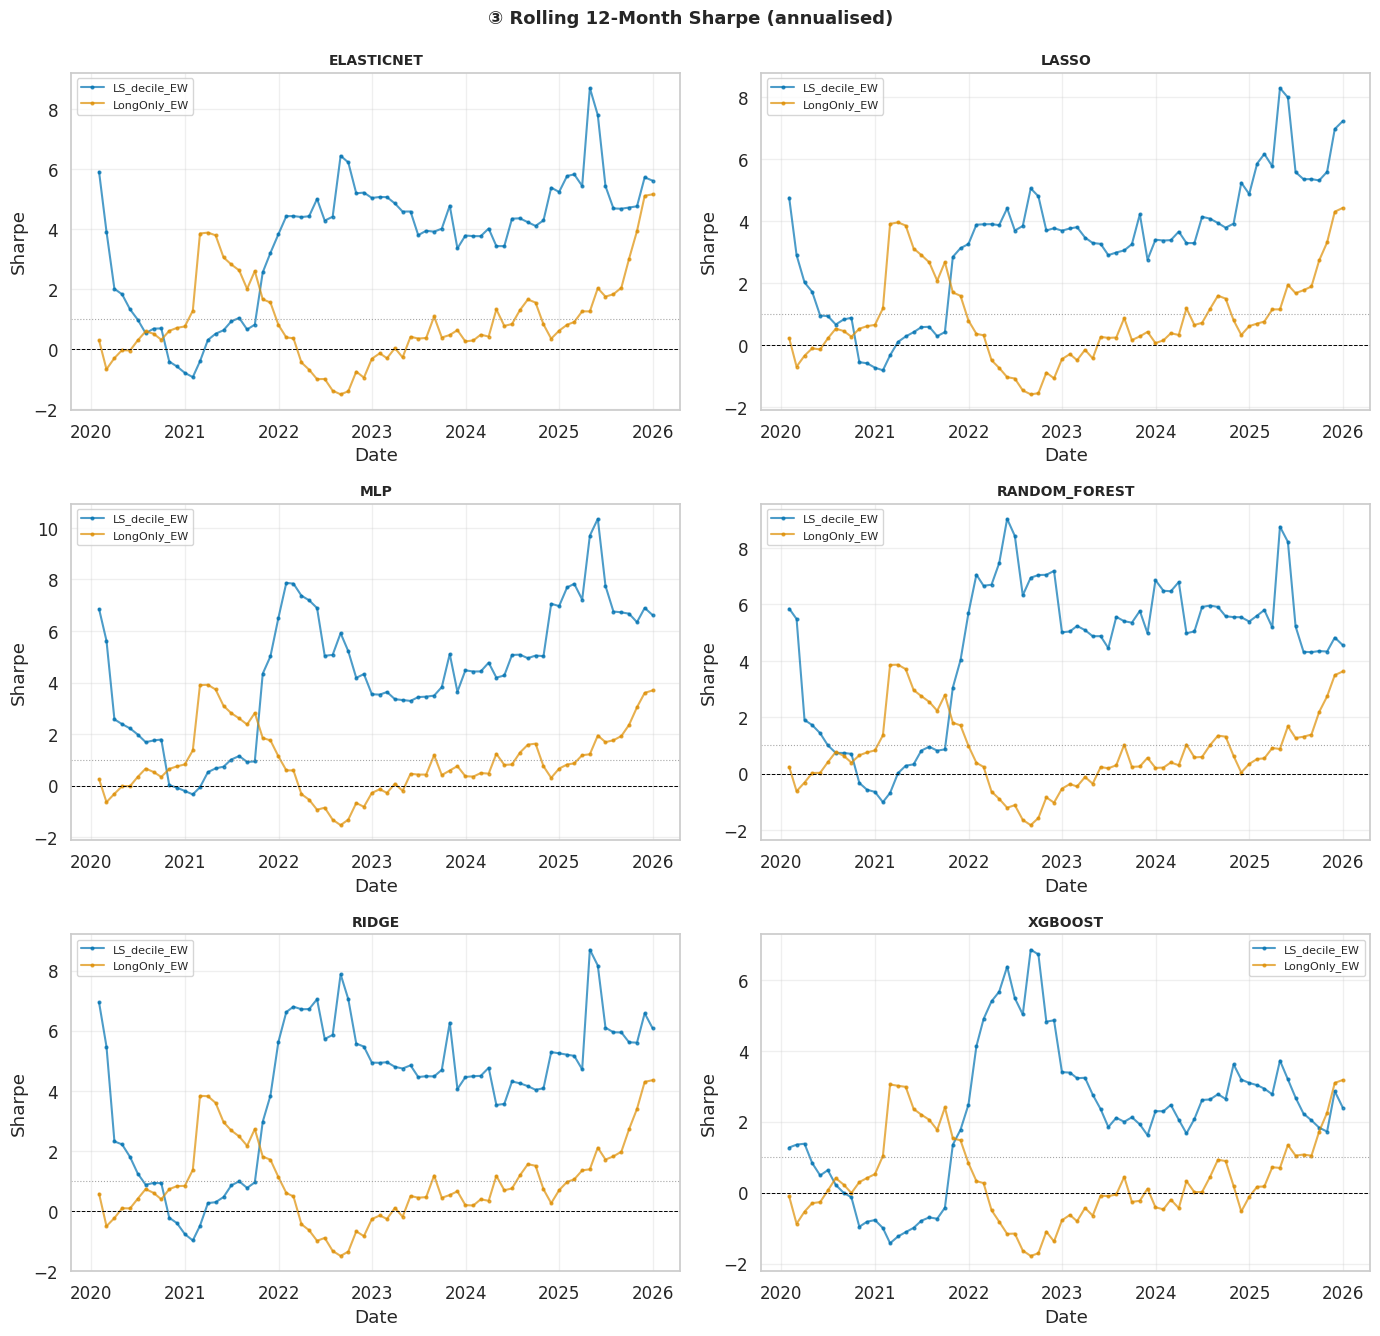

In [32]:
models = sorted(set(c[0] for c in all_ports.keys()))
n = len(models)
ncols = min(2, n); nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4.5*nrows))
axes = np.array(axes).ravel()
fig.suptitle("③ Rolling 12-Month Sharpe (annualised)",
             fontsize=13, fontweight="bold", y=0.99)

strat_colors = {"LS_decile_EW": colors[0], "LongOnly_EW": colors[1]}

for ax, m in zip(axes, models):
    for (model, strat), ret_series in all_ports.items():
        if model != m: continue
        r = ret_series.dropna()
        rs = r.rolling(12).apply(
            lambda x: x.mean() / x.std(ddof=1) * 12**0.5
            if x.std(ddof=1) > 0 else np.nan, raw=True)
        ax.plot(rs.index, rs.values, lw=1.5, 
               color=strat_colors[strat], label=strat, marker="o", 
               markersize=2, alpha=0.7)
    ax.axhline(0, color="black", lw=0.7, ls="--")
    ax.axhline(1, color="grey", lw=0.8, ls=":", alpha=0.7)
    ax.set_title(m.upper(), fontweight="bold", fontsize=10)
    ax.set_ylabel("Sharpe"); ax.set_xlabel("Date")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

for ax in axes[n:]: ax.set_visible(False)
plt.tight_layout(); plt.show()

---
## ④ Monthly Return Distributions — tail risk

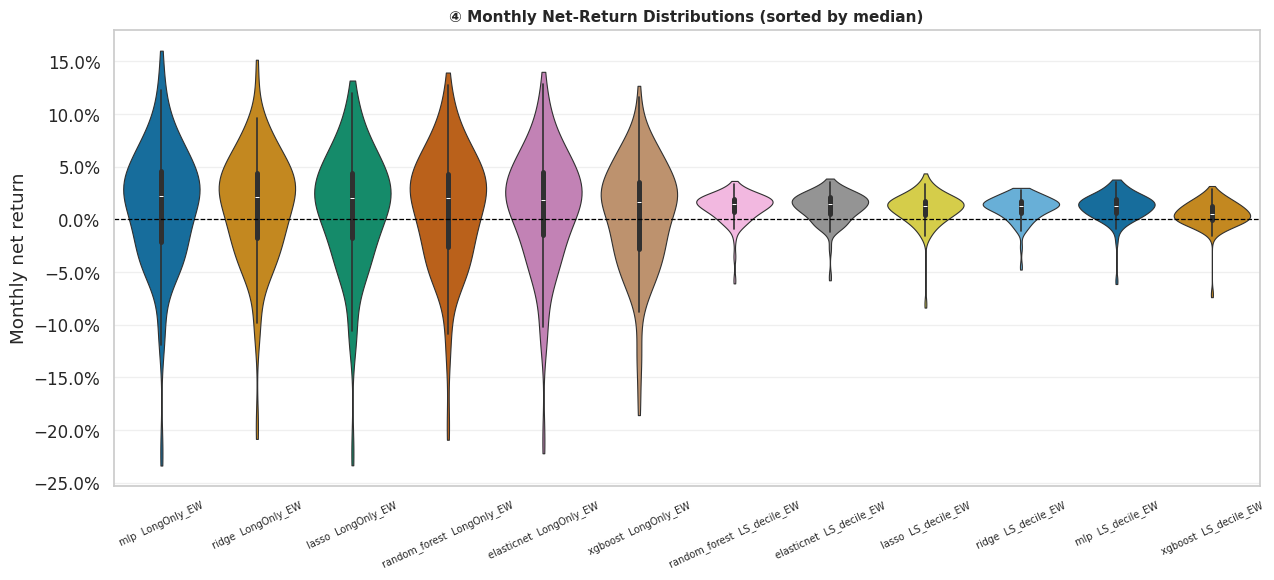

In [33]:
records = []
for (model, strat), ret_series in all_ports.items():
    for v in ret_series.dropna():
        records.append({"combo": f"{model}  {strat}", "return": v})

df_dist = pd.DataFrame(records)
order = (df_dist.groupby("combo")["return"].median()
                .sort_values(ascending=False).index.tolist())

fig, ax = plt.subplots(figsize=(13, 6))
sns.violinplot(data=df_dist, x="combo", y="return", order=order,
               ax=ax, inner="box", palette="colorblind",
               cut=0.5, linewidth=0.8)
ax.axhline(0, color="black", lw=0.9, ls="--")
ax.set_title("④ Monthly Net-Return Distributions (sorted by median)",
             fontsize=11, fontweight="bold")
ax.set_xlabel(""); ax.set_ylabel("Monthly net return")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.tick_params(axis="x", labelsize=7, rotation=25)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

---
## ⑤ Heatmap — Monthly returns by portfolio, year by year

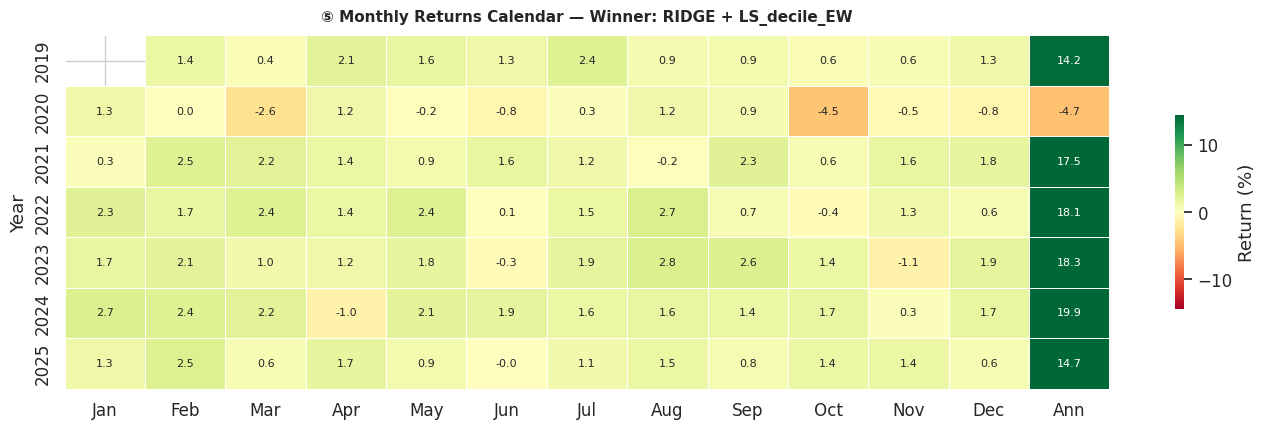

In [34]:
# Pick the winner (highest Sharpe from comp)
best_idx = comp["sharpe"].idxmax()
best_row = comp.loc[best_idx]
best_key = (best_row["model"], best_row["strategy"])

r_win = all_ports[best_key].dropna().copy()
r_win.index = pd.to_datetime(r_win.index)

tmp = r_win.rename("ret").to_frame()
tmp["year"] = tmp.index.year
tmp["month"] = tmp.index.month
pivot = tmp.pivot_table(values="ret", index="year", columns="month")
pivot.columns = ["Jan","Feb","Mar","Apr","May","Jun",
                 "Jul","Aug","Sep","Oct","Nov","Dec"][:len(pivot.columns)]
annual = r_win.groupby(r_win.index.year).apply(lambda x: (1+x).prod()-1)
pivot["Ann"] = annual.values[:len(pivot)]

vmax = np.nanpercentile(np.abs(pivot.values), 95)
fig, ax = plt.subplots(figsize=(14, max(4, len(pivot)*0.5+1)))
sns.heatmap(pivot*100, ax=ax, cmap="RdYlGn", center=0,
            vmin=-vmax*100, vmax=vmax*100,
            annot=True, fmt=".1f", linewidths=0.4, linecolor="white",
            annot_kws={"size":8},
            cbar_kws={"label":"Return (%)","shrink":0.55})
ax.set_title(f"⑤ Monthly Returns Calendar — Winner: {best_key[0].upper()} + {best_key[1]}",
             fontsize=11, fontweight="bold", pad=10)
ax.set_xlabel(""); ax.set_ylabel("Year")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

---
## 📋 Grand Comparison — Full Results

In [35]:
fmt = {
    "ann_return":    "{:.1%}",
    "ann_vol":       "{:.1%}",
    "sharpe":        "{:.2f}",
    "sortino":       "{:.2f}",
    "max_drawdown":  "{:.1%}",
    "calmar":        "{:.2f}",
    "hit_rate":      "{:.1%}",
}
fmt = {k: v for k, v in fmt.items() if k in comp.columns}

styled = (
    comp.round(4)
        .style
        .background_gradient(
            subset=[c for c in ["ann_return","sharpe","sortino","calmar"]
                    if c in comp.columns],
            cmap="Greens")
        .background_gradient(
            subset=[c for c in ["max_drawdown","ann_vol"]
                    if c in comp.columns],
            cmap="Reds_r")
        .format(fmt)
        .set_caption("Grand Comparison — all model × strategy combinations")
        .set_table_styles([{
            "selector": "caption",
            "props": [("font-size","12px"), ("font-weight","bold"),
                      ("text-align","left"), ("padding-bottom","8px")]
        }])
)
display(styled)

,model,strategy,ann_return,ann_vol,sharpe,sortino,max_drawdown,calmar,hit_rate,n_months
0,elasticnet,LS_decile_EW,17.4%,4.9%,3.56,3.48,5.8%,2.98,84.3%,83
1,elasticnet,LongOnly_EW,18.2%,19.0%,0.96,1.16,31.3%,0.58,69.9%,83
2,lasso,LS_decile_EW,15.9%,5.3%,2.97,2.01,7.8%,2.04,87.9%,83
3,lasso,LongOnly_EW,16.7%,19.3%,0.87,1.04,32.2%,0.52,66.3%,83
4,mlp,LS_decile_EW,17.8%,4.6%,3.91,2.46,5.6%,3.20,92.8%,83
5,mlp,LongOnly_EW,19.6%,19.5%,1.00,1.27,30.2%,0.65,66.3%,83
6,random_forest,LS_decile_EW,17.1%,4.8%,3.59,2.59,6.4%,2.65,90.4%,83
7,random_forest,LongOnly_EW,15.8%,19.1%,0.82,1.10,34.2%,0.46,62.6%,83
8,ridge,LS_decile_EW,16.5%,4.1%,4.00,3.40,5.0%,3.32,90.4%,83
9,ridge,LongOnly_EW,18.9%,17.9%,1.05,1.34,26.9%,0.70,66.3%,83
